# Design, Implementation, and Analysis of a Lightweight Transformer Language Model

**Applied Machine Learning HW3 - Transformer is All You Need**

In this assignment, we implement a lightweight Transformer-based language model from scratch using PyTorch and train it on the Tiny Shakespeare corpus. The task is to predict the next token in a sequence, effectively modeling the distribution $( P(x_t \mid x_1, \dots, x_{t-1}) )$. Despite its simplicity, this setup captures the essential principles behind modern generative language models.

We focus on building the core components of a Transformer block, including positional encoding, masked self-attention, residual connections, and feed-forward networks. The model is trained using cross-entropy loss and evaluated using perplexity, a standard metric for language modeling tasks. Additionally, we analyze attention patterns to better understand how the model captures contextual dependencies in text.



## 0) Importing Libraries | Setup

In [1]:
!pip install tokenizers

In [2]:
import time
import copy
import math
import torch
import random
import numpy as np
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F

from google.colab import drive
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder
from torch.utils.data import TensorDataset, DataLoader, random_split

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # ensures reproducibility (may slightly slow down training)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## 1) Data Preperation

### a. Loading the Tiny Shakespeare text

We use the Tiny Shakespeare corpus, a small collection of Shakespeare's works commonly used for character- and token-level language modeling tasks. The dataset provides a compact yet expressive benchmark for training and evaluating generative models.

In [4]:
drive.mount('/content/drive')

with open('/content/drive/MyDrive/HomeworksBT/AppliedML/input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(len(text))
print(text[:500])

Mounted at /content/drive
1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


### b. Tokenization (Byte-Pair Encoding)

We employ Byte Pair Encoding (BPE) as a subword-level tokenization strategy to convert raw text into integer token sequences. Unlike character-level tokenization, BPE iteratively merges frequently occurring character pairs into subword units, enabling the model to capture meaningful linguistic patterns such as prefixes, suffixes, and common word fragments (e.g., 'ing', 'tion', 'the').

This approach provides a balance between vocabulary size and expressiveness, improving both computational efficiency and the model's ability to generalize across similar words.

To maintain a lightweight experimental setup, the vocabulary size is constrained to a maximum of 500 tokens. The tokenizer is trained directly on the Tiny Shakespeare corpus, ensuring that the learned subword units are tailored to the dataset.


In [5]:
# initialize tokenizer
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))

# use ByteLevel pre-tokenization
tokenizer.pre_tokenizer = ByteLevel()

# add ByteLevel decoder
tokenizer.decoder = ByteLevelDecoder()

# trainer with vocab <= 500
trainer = BpeTrainer(
    vocab_size=500,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
)

# train tokenizer on the Shakespeare text file
tokenizer.train(
    ['/content/drive/MyDrive/HomeworksBT/AppliedML/input.txt'],
    trainer
)

# encode the full text
encoded = tokenizer.encode(text)
token_ids = encoded.ids

print("Vocab size:", tokenizer.get_vocab_size())
print("First 50 token ids:", token_ids[:50])
print("First 20 tokens:", encoded.tokens[:20])
print("\nDecoded sample:")
print(tokenizer.decode(token_ids[:50]))

Vocab size: 500
First 50 token ids: [494, 151, 89, 49, 66, 97, 12, 67, 16, 45, 372, 152, 403, 126, 132, 235, 65, 85, 189, 60, 158, 8, 495, 135, 432, 10, 67, 67, 15, 88, 12, 67, 33, 56, 405, 8, 432, 10, 67, 67, 20, 387, 151, 89, 49, 66, 97, 12, 67, 39]
First 20 tokens: ['ĠFirst', 'ĠC', 'it', 'i', 'z', 'en', ':', 'Ċ', 'B', 'e', 'fore', 'Ġwe', 'Ġpro', 'ce', 'ed', 'Ġan', 'y', 'Ġf', 'ur', 't']

Decoded sample:
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
Y


### c. Sequence Formatting

We transform the tokenized text into overlapping fixed-length sequences to prepare the data for next-token prediction. Each sequence consists of a contiguous block of tokens of length N (e.g., 50), preserving the natural order of the text.

For each sequence, the input corresponds to the first N tokens, while the target is defined as the same sequence shifted by one position. This formulation enables the model to learn the conditional probability of the next token given its preceding context.

By using overlapping windows across the entire corpus, we maximize data utilization and expose the model to diverse contextual patterns. This approach is well-suited for autoregressive language modeling, where predictions are made sequentially based on prior tokens.

In [6]:
context_length = 50

def create_sequences(token_ids, context_length):
    inputs = []
    targets = []

    for i in range(len(token_ids) - context_length):
        x = token_ids[i : i + context_length]
        y = token_ids[i + 1 : i + context_length + 1]

        inputs.append(x)
        targets.append(y)

    return torch.tensor(inputs, dtype=torch.long), torch.tensor(targets, dtype=torch.long)

X, Y = create_sequences(token_ids, context_length)

print("Input shape:", X.shape)
print("Target shape:", Y.shape)
print("\nSample input IDs:", X[0][:10])
print("Sample target IDs:", Y[0][:10])

Input shape: torch.Size([529502, 50])
Target shape: torch.Size([529502, 50])

Sample input IDs: tensor([494, 151,  89,  49,  66,  97,  12,  67,  16,  45])
Sample target IDs: tensor([151,  89,  49,  66,  97,  12,  67,  16,  45, 372])


### d. Data Split

To evaluate the model’s ability to generalize, the sequence dataset is divided into training and validation subsets using an 80/20 split. The training portion is used to optimize model parameters, while the validation portion is used to monitor performance on unseen sequences during training.

Consistent with the assignment specification, no separate test set is introduced in this stage. This lightweight setup is sufficient for experimentation and allows validation perplexity to serve as the primary evaluation metric.

In [7]:
# create dataset
dataset = TensorDataset(X, Y)

# split sizes
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

# reproducible split
train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# dataloaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print("Total:", len(dataset))
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

Total: 529502
Train: 423601
Val: 105901


In [8]:
xb, yb = next(iter(train_loader))
print("Input shape :", xb.shape)
print("Target shape:", yb.shape)

Input shape : torch.Size([64, 50])
Target shape: torch.Size([64, 50])


## 2. Implementing a Tiny Transformer

We implement a lightweight Transformer-based language model for next-token prediction. The model is composed of token embeddings with sinusoidal positional encodings, stacked causal self-attention blocks, feed-forward sublayers, residual connections, and RMSNorm.

To satisfy the assignment constraints, we use a compact architecture with two Transformer blocks and a hidden size of 128. This design is expressive enough to learn meaningful sequential dependencies while remaining computationally efficient for experimentation on the Tiny Shakespeare corpus.

### a. Positional Encoding

Because the Transformer does not inherently encode sequence order, positional information must be added explicitly. We use sinusoidal positional encodings, which inject deterministic position-dependent patterns into token embeddings and allow the model to distinguish tokens based on both identity and location in the sequence.

In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

### b. RMSNorm

To stabilize training, we use RMSNorm instead of LayerNorm, as requested in the assignment. RMSNorm normalizes activations using their root-mean-square magnitude while preserving simplicity and computational efficiency. This helps maintain stable feature scales across Transformer layers.

In [10]:
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        rms = x.pow(2).mean(dim=-1, keepdim=True).add(self.eps).sqrt()
        return self.scale * (x / rms)

### c. Causal Self-Attention

The self-attention module allows each token to attend to previous tokens in the same sequence and build context-aware representations. To enforce autoregressive next-token prediction, a causal mask is applied so that each position can only attend to itself and earlier positions, never to future tokens.

In [11]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x, return_attention=False):
        B, T, C = x.shape

        Q = self.q_proj(x)  # [B, T, C]
        K = self.k_proj(x)
        V = self.v_proj(x)

        # reshape into heads
        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)  # [B, H, T, D]
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        # scaled dot-product attention
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.head_dim)  # [B, H, T, T]

        # causal mask: block future tokens
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float("-inf"))

        attn = torch.softmax(scores, dim=-1)  # [B, H, T, T]
        out = attn @ V  # [B, H, T, D]

        # combine heads
        out = out.transpose(1, 2).contiguous().view(B, T, C)  # [B, T, C]
        out = self.out_proj(out)

        if return_attention:
            return out, attn
        return out

### d. Debugging Against a Reference

To verify the correctness of the custom self-attention implementation, we compare its output against PyTorch’s built-in `nn.MultiheadAttention`. By feeding both modules the same input and aligning their projection weights, we can confirm that the custom attention layer behaves as expected under the same causal masking setup.

This debugging step is used only for verification and does not replace the custom Transformer implementation required for the assignment.

In [12]:
def compare_attention_with_pytorch(d_model=128, num_heads=4, batch_size=2, seq_len=6, seed=42):
    torch.manual_seed(seed)

    # random input
    x = torch.randn(batch_size, seq_len, d_model)

    # your custom attention
    custom_attn = MultiHeadSelfAttention(d_model=d_model, num_heads=num_heads)

    # pytorch reference attention
    ref_attn = nn.MultiheadAttention(
        embed_dim=d_model,
        num_heads=num_heads,
        batch_first=True,
        bias=True
    )

    # copy weights from custom module into PyTorch reference
    # PyTorch stores q,k,v projections in one large matrix
    with torch.no_grad():
        ref_attn.in_proj_weight.copy_(torch.cat([
            custom_attn.q_proj.weight,
            custom_attn.k_proj.weight,
            custom_attn.v_proj.weight
        ], dim=0))

        ref_attn.in_proj_bias.copy_(torch.cat([
            custom_attn.q_proj.bias,
            custom_attn.k_proj.bias,
            custom_attn.v_proj.bias
        ], dim=0))

        ref_attn.out_proj.weight.copy_(custom_attn.out_proj.weight)
        ref_attn.out_proj.bias.copy_(custom_attn.out_proj.bias)

    # causal mask for PyTorch reference
    causal_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()

    # outputs
    custom_out, custom_weights = custom_attn(x, return_attention=True)
    ref_out, ref_weights = ref_attn(
        x, x, x,
        attn_mask=causal_mask,
        need_weights=True,
        average_attn_weights=False
    )

    # compare
    max_diff_out = (custom_out - ref_out).abs().max().item()
    max_diff_attn = (custom_weights - ref_weights).abs().max().item()

    print("Custom output shape     :", custom_out.shape)
    print("Reference output shape  :", ref_out.shape)
    print("Max abs diff (output)   :", max_diff_out)
    print("Max abs diff (attention):", max_diff_attn)

    return custom_out, ref_out, custom_weights, ref_weights

In [13]:
custom_out, ref_out, custom_weights, ref_weights = compare_attention_with_pytorch()

Custom output shape     : torch.Size([2, 6, 128])
Reference output shape  : torch.Size([2, 6, 128])
Max abs diff (output)   : 1.7881393432617188e-07
Max abs diff (attention): 5.960464477539063e-08


The custom self-attention implementation matches PyTorch’s reference almost exactly, with only negligible numerical differences, confirming its correctness.

### e. Feed-Forward Network

Following the attention layer, each token representation is passed through a position-wise feed-forward network. This sublayer introduces non-linearity and expands the representational capacity of the model, allowing it to learn richer transformations beyond attention-based context mixing.

In [14]:
class FeedForward(nn.Module):
    def __init__(self, d_model, ff_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, d_model)
        )

    def forward(self, x):
        return self.net(x)

### f. Transformer Block

Each Transformer block consists of a causal self-attention sublayer followed by a feed-forward sublayer, with RMSNorm and residual connections applied around both components. Residual pathways help preserve information and improve gradient flow, making training more stable even in deeper architectures.

In [15]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, num_heads)
        self.norm2 = RMSNorm(d_model)
        self.ff = FeedForward(d_model, ff_dim)

    def forward(self, x, return_attention=False):
        if return_attention:
            attn_out, attn_weights = self.attn(self.norm1(x), return_attention=True)
            x = x + attn_out
            x = x + self.ff(self.norm2(x))
            return x, attn_weights
        else:
            x = x + self.attn(self.norm1(x))
            x = x + self.ff(self.norm2(x))
            return x

### g. Full Tiny Transformer Language Model

The complete language model combines token embeddings, positional encodings, two stacked Transformer blocks, a final RMSNorm layer, and a linear output head that projects hidden states to vocabulary logits. These logits are used to predict the next token at each position in the sequence.

In [16]:
class TinyTransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_heads=4, num_layers=2, ff_dim=256, max_len=500):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_len)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, ff_dim) for _ in range(num_layers)
        ])

        self.norm_final = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, return_attention=False):
        x = self.token_embedding(x)      # [B, T, d_model]
        x = self.pos_encoding(x)         # [B, T, d_model]

        attention_maps = []

        for block in self.blocks:
            if return_attention:
                x, attn = block(x, return_attention=True)
                attention_maps.append(attn)
            else:
                x = block(x)

        x = self.norm_final(x)
        logits = self.lm_head(x)         # [B, T, vocab_size]

        if return_attention:
            return logits, attention_maps
        return logits

## 3. Training and Evaluation

### a. Model Initialization

The Transformer is initialized using a lightweight configuration with two Transformer blocks, hidden size 128, and four attention heads. This satisfies the assignment recommendation while keeping the model small enough for efficient experimentation.

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_config = {
    "vocab_size": tokenizer.get_vocab_size(),
    "d_model": 128,
    "num_heads": 4,
    "num_layers": 2,
    "ff_dim": 256,
    "max_len": context_length
}

def build_model(config):
    model = TinyTransformerLM(
        vocab_size=config["vocab_size"],
        d_model=config["d_model"],
        num_heads=config["num_heads"],
        num_layers=config["num_layers"],
        ff_dim=config["ff_dim"],
        max_len=config["max_len"]
    ).to(device)
    return model

print(build_model(base_config))

TinyTransformerLM(
  (token_embedding): Embedding(500, 128)
  (pos_encoding): PositionalEncoding()
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (norm1): RMSNorm()
      (attn): MultiHeadSelfAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
      )
      (norm2): RMSNorm()
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=256, out_features=128, bias=True)
        )
      )
    )
  )
  (norm_final): RMSNorm()
  (lm_head): Linear(in_features=128, out_features=500, bias=True)
)


### b. Helper Functions

To prevent code repetition, training, validation, perplexity computation, and checkpoint management are implemented as reusable helper functions. Validation and visualization are always performed with `torch.no_grad()` to reduce memory usage and runtime, as recommended in the assignment.

In [18]:
criterion = nn.CrossEntropyLoss()

In [19]:
def compute_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                yb.reshape(-1)
            )
            total_loss += loss.item()

    return total_loss / len(loader)

In [20]:
def compute_perplexity(loss_value):
    return math.exp(loss_value)

In [21]:
def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip=None):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            yb.reshape(-1)
        )

        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [22]:
def train_model_with_checkpoints(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=10,
    device="cpu",
    grad_clip=1.0,
    checkpoint_epochs=None
):
    if checkpoint_epochs is None:
        checkpoint_epochs = [1, 5, epochs]

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_ppl": [],
        "epoch_time_sec": []
    }

    checkpoints = {}
    best_model_state = None
    best_val_loss = float("inf")

    for epoch in range(epochs):
        start_time = time.time()

        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            grad_clip=grad_clip
        )

        val_loss = compute_loss(model, val_loader, criterion, device)
        val_ppl = compute_perplexity(val_loss)

        epoch_time = time.time() - start_time

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_ppl"].append(val_ppl)
        history["epoch_time_sec"].append(epoch_time)

        # save requested checkpoints
        if (epoch + 1) in checkpoint_epochs:
            checkpoints[epoch + 1] = copy.deepcopy(model.state_dict())

        # track best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val PPL: {val_ppl:.4f} | "
            f"Time: {epoch_time:.2f}s"
        )

    # restore best model at end
    model.load_state_dict(best_model_state)

    return model, history, checkpoints

### c. Main Training Run

The baseline model is trained once using the unified training pipeline. During this run, training and validation metrics are recorded and selected intermediate checkpoints are saved, allowing later analysis of attention evolution without retraining the model.

In [23]:
model = build_model(base_config)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

model, history, checkpoints = train_model_with_checkpoints(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=10,
    device=device,
    grad_clip=1.0,
    checkpoint_epochs=[1, 5, 10]
)

Epoch 1/10 | Train Loss: 2.7588 | Val Loss: 2.4612 | Val PPL: 11.7184 | Time: 67.53s
Epoch 2/10 | Train Loss: 2.3633 | Val Loss: 2.2991 | Val PPL: 9.9655 | Time: 66.73s
Epoch 3/10 | Train Loss: 2.2435 | Val Loss: 2.2131 | Val PPL: 9.1438 | Time: 66.52s
Epoch 4/10 | Train Loss: 2.1708 | Val Loss: 2.1565 | Val PPL: 8.6406 | Time: 66.95s
Epoch 5/10 | Train Loss: 2.1204 | Val Loss: 2.1154 | Val PPL: 8.2933 | Time: 66.68s
Epoch 6/10 | Train Loss: 2.0831 | Val Loss: 2.0833 | Val PPL: 8.0308 | Time: 66.41s
Epoch 7/10 | Train Loss: 2.0535 | Val Loss: 2.0554 | Val PPL: 7.8096 | Time: 66.36s
Epoch 8/10 | Train Loss: 2.0296 | Val Loss: 2.0336 | Val PPL: 7.6416 | Time: 67.02s
Epoch 9/10 | Train Loss: 2.0091 | Val Loss: 2.0185 | Val PPL: 7.5270 | Time: 67.79s
Epoch 10/10 | Train Loss: 1.9916 | Val Loss: 2.0032 | Val PPL: 7.4126 | Time: 67.70s


### d. Plotting Training and Validation Loss Curves

Training and validation loss curves are plotted over epochs to assess optimization behavior and stability. These curves make it possible to evaluate convergence, compare experimental settings, and detect signs of unstable learning or overfitting.

----

**Analysis:** Both training and validation loss decrease steadily over epochs, indicating stable and consistent learning. The gap between the two curves remains small, suggesting good generalization and no signs of overfitting. Training loss is initially higher than validation loss, likely due to regularization during training, but they quickly align. Toward later epochs, both curves begin to flatten, indicating the model is approaching convergence and further improvements are limited.

In [90]:
def plot_loss_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Training Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

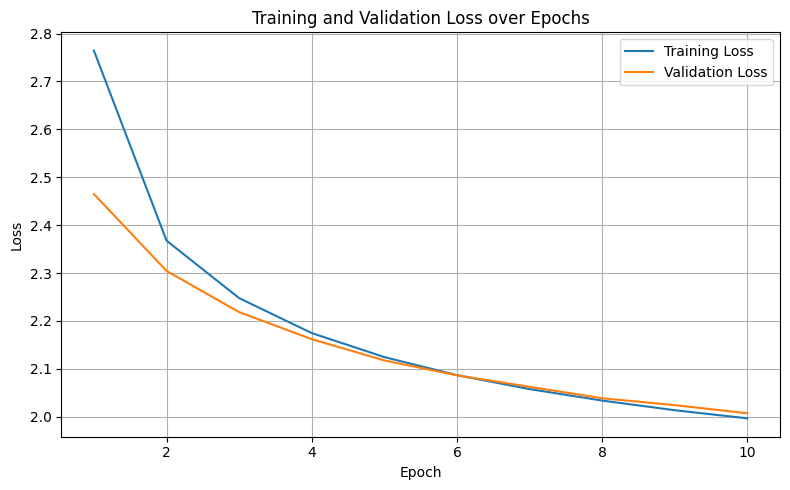

In [91]:
plot_loss_curves(history)

### e. Hyperparameter Experiments

To determine which hyperparameters most strongly affect training stability designed a compact experiment around three factors: learning rate, context length, and model size. Stability can be assessed through the smoothness of the loss curves, final validation perplexity, and whether training remains well-behaved without divergence.

A practical experiment plan is:
- Learning rate: `1e-4`, `3e-4`, `1e-3`
- Context length: `32` and `50`
- Model size: `64` and `128`

In [54]:
# Rebuilding Sequence Dataset for Any Context Length

def create_sequences(token_ids, context_length):
    inputs = []
    targets = []

    for i in range(len(token_ids) - context_length):
        x = token_ids[i : i + context_length]
        y = token_ids[i + 1 : i + context_length + 1]

        inputs.append(x)
        targets.append(y)

    return torch.tensor(inputs, dtype=torch.long), torch.tensor(targets, dtype=torch.long)

def build_dataloaders_for_context(token_ids, context_length, batch_size=64, seed=42):
    X_ctx, Y_ctx = create_sequences(token_ids, context_length)

    dataset_ctx = TensorDataset(X_ctx, Y_ctx)

    train_size = int(0.8 * len(dataset_ctx))
    val_size = len(dataset_ctx) - train_size

    train_dataset_ctx, val_dataset_ctx = random_split(
        dataset_ctx,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(seed)
    )

    train_loader_ctx = DataLoader(train_dataset_ctx, batch_size=batch_size, shuffle=True)
    val_loader_ctx = DataLoader(val_dataset_ctx, batch_size=batch_size, shuffle=False)

    return train_loader_ctx, val_loader_ctx, train_dataset_ctx, val_dataset_ctx

In [55]:
# Reusable Plotter for Validation Loss Experiments

def plot_experiment_losses(results, label_key, title):
    plt.figure(figsize=(10, 6))

    for result in results:
        epochs = range(1, len(result["history"]["val_loss"]) + 1)

        # validation loss
        plt.plot(
            epochs,
            result["history"]["val_loss"],
            label=f"{label_key}={result[label_key]} (val)"
        )

        # training loss
        plt.plot(
            epochs,
            result["history"]["train_loss"],
            linestyle="--",
            alpha=0.7,
            label=f"{label_key}={result[label_key]} (train)"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [56]:
def run_experiment(
    config,
    train_loader,
    val_loader,
    lr=3e-4,
    epochs=6,
    device="cpu",
    grad_clip=1.0
):
    exp_model = build_model(config)
    exp_optimizer = optim.Adam(exp_model.parameters(), lr=lr)

    exp_model, exp_history, _ = train_model_with_checkpoints(
        model=exp_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=exp_optimizer,
        epochs=epochs,
        device=device,
        grad_clip=grad_clip,
        checkpoint_epochs=[]
    )

    result = {
        "config": copy.deepcopy(config),
        "lr": lr,
        "best_val_loss": min(exp_history["val_loss"]),
        "best_val_ppl": min(exp_history["val_ppl"]),
        "history": exp_history
    }
    return result

#### Learning Rate Experiments

The learning rate has a clear impact on convergence behavior and stability.
- lr = 0.001 converges the fastest and reaches the lowest loss, with smooth and consistent decrease across epochs.
- lr = 0.0003 shows stable but slower convergence.
- lr = 0.0001 is the slowest, with higher loss throughout training.

All curves are relatively smooth (no oscillations), indicating stable training, but smaller learning rates lead to underfitting due to slow progress, while a moderately larger learning rate improves both speed and final performance.

In [31]:
lr_results = []

for lr in [1e-4, 3e-4, 1e-3]:
    print(f"\nRunning learning rate experiment: lr={lr}")

    result = run_experiment(
        config=base_config,
        train_loader=train_loader,
        val_loader=val_loader,
        lr=lr,
        epochs=6,
        device=device
    )

    lr_results.append(result)


Running learning rate experiment: lr=0.0001
Epoch 1/6 | Train Loss: 3.5747 | Val Loss: 3.0766 | Val PPL: 21.6842 | Time: 66.57s
Epoch 2/6 | Train Loss: 2.9292 | Val Loss: 2.8263 | Val PPL: 16.8833 | Time: 66.48s
Epoch 3/6 | Train Loss: 2.7561 | Val Loss: 2.7034 | Val PPL: 14.9307 | Time: 67.08s
Epoch 4/6 | Train Loss: 2.6554 | Val Loss: 2.6208 | Val PPL: 13.7471 | Time: 66.65s
Epoch 5/6 | Train Loss: 2.5839 | Val Loss: 2.5597 | Val PPL: 12.9319 | Time: 66.57s
Epoch 6/6 | Train Loss: 2.5281 | Val Loss: 2.5100 | Val PPL: 12.3054 | Time: 66.40s

Running learning rate experiment: lr=0.0003
Epoch 1/6 | Train Loss: 3.0919 | Val Loss: 2.7100 | Val PPL: 15.0295 | Time: 66.43s
Epoch 2/6 | Train Loss: 2.6042 | Val Loss: 2.5272 | Val PPL: 12.5183 | Time: 66.95s
Epoch 3/6 | Train Loss: 2.4672 | Val Loss: 2.4278 | Val PPL: 11.3338 | Time: 66.35s
Epoch 4/6 | Train Loss: 2.3799 | Val Loss: 2.3544 | Val PPL: 10.5321 | Time: 66.53s
Epoch 5/6 | Train Loss: 2.3162 | Val Loss: 2.3014 | Val PPL: 9.9880 | 

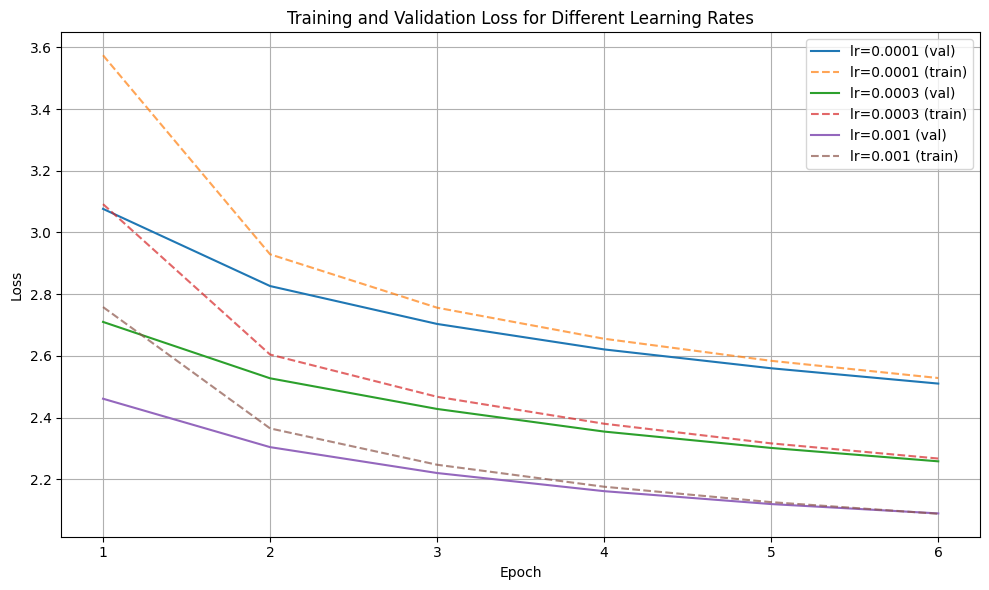

In [32]:
plot_experiment_losses(
    lr_results,
    label_key="lr",
    title="Training and Validation Loss for Different Learning Rates"
)

#### Context Length Experiments

Increasing context length improves performance without harming stability.

- context_length = 50 consistently achieves lower training and validation loss than 32.
- Both settings exhibit very similar curve shapes and smooth convergence.

This suggests that longer context provides better sequence understanding, but does not significantly change training dynamics or stability, only the final performance level.

In [57]:
context_results = []

for ctx_len in [32, 50]:
    print(f"\nRunning context length experiment: context_length={ctx_len}")

    train_loader_ctx, val_loader_ctx, _, _ = build_dataloaders_for_context(
        token_ids=token_ids,
        context_length=ctx_len,
        batch_size=64,
        seed=42
    )

    ctx_config = copy.deepcopy(base_config)
    ctx_config["max_len"] = ctx_len

    result = run_experiment(
        config=ctx_config,
        train_loader=train_loader_ctx,
        val_loader=val_loader_ctx,
        lr=3e-4,
        epochs=6,
        device=device
    )

    result["context_length"] = ctx_len
    context_results.append(result)


Running context length experiment: context_length=32
Epoch 1/6 | Train Loss: 3.1424 | Val Loss: 2.7661 | Val PPL: 15.8962 | Time: 65.67s
Epoch 2/6 | Train Loss: 2.6670 | Val Loss: 2.5961 | Val PPL: 13.4115 | Time: 65.41s
Epoch 3/6 | Train Loss: 2.5379 | Val Loss: 2.5029 | Val PPL: 12.2177 | Time: 65.21s
Epoch 4/6 | Train Loss: 2.4552 | Val Loss: 2.4347 | Val PPL: 11.4121 | Time: 65.64s
Epoch 5/6 | Train Loss: 2.3937 | Val Loss: 2.3865 | Val PPL: 10.8751 | Time: 65.39s
Epoch 6/6 | Train Loss: 2.3456 | Val Loss: 2.3489 | Val PPL: 10.4738 | Time: 65.78s

Running context length experiment: context_length=50
Epoch 1/6 | Train Loss: 3.1002 | Val Loss: 2.7134 | Val PPL: 15.0811 | Time: 67.28s
Epoch 2/6 | Train Loss: 2.6035 | Val Loss: 2.5280 | Val PPL: 12.5282 | Time: 67.24s
Epoch 3/6 | Train Loss: 2.4639 | Val Loss: 2.4230 | Val PPL: 11.2794 | Time: 67.17s
Epoch 4/6 | Train Loss: 2.3745 | Val Loss: 2.3477 | Val PPL: 10.4613 | Time: 67.42s
Epoch 5/6 | Train Loss: 2.3098 | Val Loss: 2.2951 | 

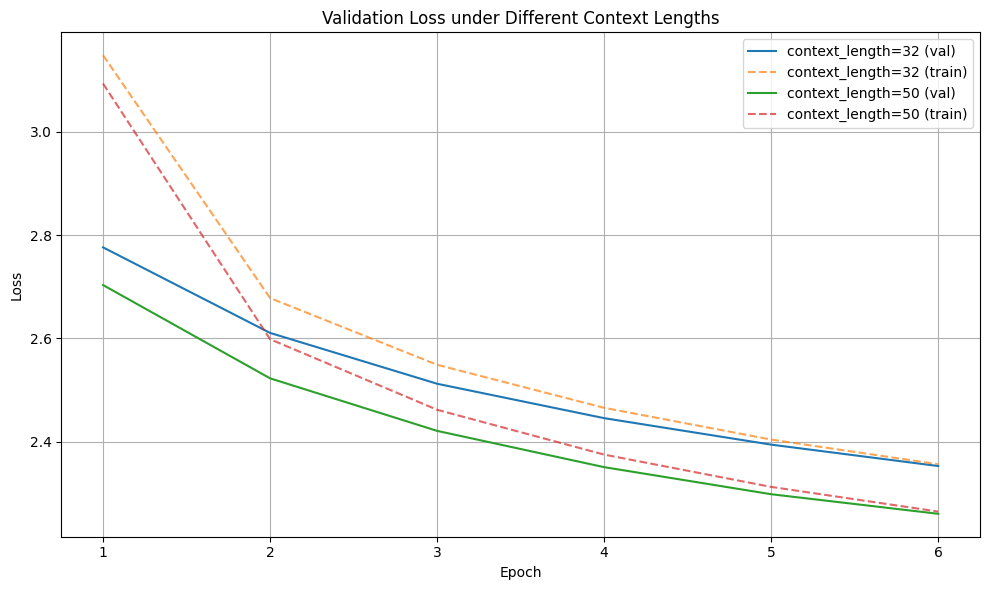

In [61]:
plot_experiment_losses( #change it with plot_experiment_losses
    context_results,
    label_key="context_length",
    title="Validation Loss under Different Context Lengths"
)

#### Model Size Experiment

Model size has a strong effect on both performance and convergence efficiency.

- d_model = 128 achieves substantially lower loss and converges faster.
- d_model = 64 shows slower learning and higher final loss.

Despite this difference, both configurations remain stable (smooth curves, no divergence). Larger models improve representational capacity without introducing instability in this setup.

In [59]:
model_size_results = []

for d_model in [64, 128]:
    print(f"\nRunning model size experiment: d_model={d_model}")

    model_config = copy.deepcopy(base_config)
    model_config["d_model"] = d_model
    model_config["ff_dim"] = d_model * 2   # keep feed-forward proportional

    result = run_experiment(
        config=model_config,
        train_loader=train_loader,
        val_loader=val_loader,
        lr=3e-4,
        epochs=6,
        device=device
    )

    result["d_model"] = d_model
    model_size_results.append(result)


Running model size experiment: d_model=64
Epoch 1/6 | Train Loss: 3.5272 | Val Loss: 3.1122 | Val PPL: 22.4708 | Time: 66.88s
Epoch 2/6 | Train Loss: 3.0077 | Val Loss: 2.9361 | Val PPL: 18.8419 | Time: 66.99s
Epoch 3/6 | Train Loss: 2.8911 | Val Loss: 2.8593 | Val PPL: 17.4494 | Time: 67.01s
Epoch 4/6 | Train Loss: 2.8298 | Val Loss: 2.8112 | Val PPL: 16.6298 | Time: 67.34s
Epoch 5/6 | Train Loss: 2.7901 | Val Loss: 2.7786 | Val PPL: 16.0959 | Time: 67.99s
Epoch 6/6 | Train Loss: 2.7616 | Val Loss: 2.7534 | Val PPL: 15.6963 | Time: 68.54s

Running model size experiment: d_model=128
Epoch 1/6 | Train Loss: 3.1032 | Val Loss: 2.7110 | Val PPL: 15.0442 | Time: 67.17s
Epoch 2/6 | Train Loss: 2.6052 | Val Loss: 2.5301 | Val PPL: 12.5554 | Time: 66.93s
Epoch 3/6 | Train Loss: 2.4661 | Val Loss: 2.4263 | Val PPL: 11.3165 | Time: 67.85s
Epoch 4/6 | Train Loss: 2.3770 | Val Loss: 2.3520 | Val PPL: 10.5062 | Time: 67.03s
Epoch 5/6 | Train Loss: 2.3124 | Val Loss: 2.2962 | Val PPL: 9.9367 | Tim

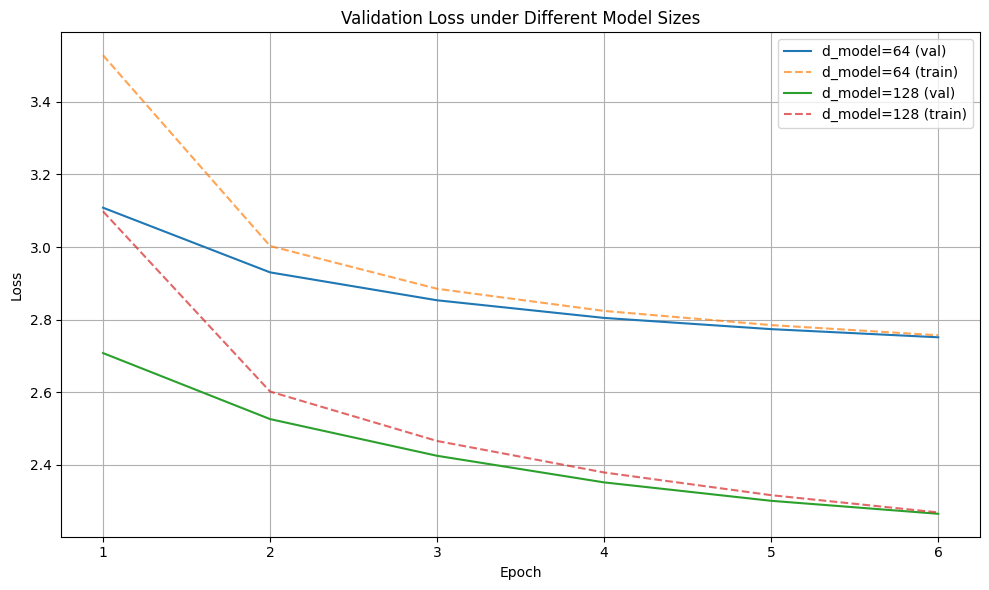

In [60]:
plot_experiment_losses(
    model_size_results,
    label_key="d_model",
    title="Validation Loss under Different Model Sizes"
)

#### Summarizing All Experiments

Learning rate has the greatest impact on stability.

It directly controls the optimization step size and affects convergence speed and smoothness.
Poor choices (too small or too large) would lead to slow learning or potential instability (even though the tested values are all stable).
In contrast, context length and model size mainly shift performance levels, not the stability of training dynamics.

In [37]:
def summarize_results(results, label_key):
    for result in results:
        print(
            f"{label_key}={result[label_key]} | "
            f"Best Val Loss: {result['best_val_loss']:.4f} | "
            f"Best Val PPL: {result['best_val_ppl']:.4f}"
        )

In [38]:
print("\nLearning Rate Results")
summarize_results(lr_results, "lr")

print("\nContext Length Results")
summarize_results(context_results, "context_length")

print("\nModel Size Results")
summarize_results(model_size_results, "d_model")


Learning Rate Results
lr=0.0001 | Best Val Loss: 2.5100 | Best Val PPL: 12.3054
lr=0.0003 | Best Val Loss: 2.2580 | Best Val PPL: 9.5635
lr=0.001 | Best Val Loss: 2.0891 | Best Val PPL: 8.0775

Context Length Results
context_length=32 | Best Val Loss: 2.3525 | Best Val PPL: 10.5117
context_length=50 | Best Val Loss: 2.2600 | Best Val PPL: 9.5829

Model Size Results
d_model=64 | Best Val Loss: 2.7513 | Best Val PPL: 15.6626
d_model=128 | Best Val Loss: 2.2647 | Best Val PPL: 9.6286


### f. Validation Perplexity

Perplexity is reported as the primary evaluation metric for next-token prediction. It is computed as the exponential of the validation cross-entropy loss, with lower values indicating better predictive performance on unseen sequences.

---

**Analysis:** The model achieves a best validation loss of 2.0073, corresponding to a perplexity of 7.4431, indicating a strong ability to predict next tokens. Since perplexity measures uncertainty, a value around 7.4 suggests the model is making relatively confident and accurate predictions. Combined with the smooth loss curves, this result confirms that the model has learned meaningful patterns from the data and generalizes well without overfitting.

In [92]:
best_val_loss = min(history["val_loss"])
best_val_ppl = compute_perplexity(best_val_loss)

print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Best Validation Perplexity: {best_val_ppl:.4f}")

Best Validation Loss: 2.0073
Best Validation Perplexity: 7.4431


### g. Attention Heatmaps for Sample Sequences

To interpret what the Transformer has learned, we visualize attention heatmaps for sample validation sequences. These heatmaps show how strongly each token attends to earlier tokens in the same sequence. Because causal masking is applied, the resulting attention matrices should follow a lower-triangular structure.

In [29]:
def get_token_labels(tokenizer, token_ids):
    labels = []

    for tid in token_ids:
        tok = tokenizer.decode([tid])

        tok = tok.replace("Ġ", "")
        tok = tok.replace("Ċ", "")

        tok = tok.strip()

        if tok == "":
            tok = "_"

        labels.append(tok)

    return labels

In [30]:
def plot_attention_from_text(
    model,
    tokenizer,
    text,
    device,
    layer_idx=0,
    head_idx=1,
    max_tokens=20
):
    model.eval()

    # encode text
    token_ids = tokenizer.encode(text).ids[:max_tokens]
    x_sample = torch.tensor(token_ids, dtype=torch.long).unsqueeze(0).to(device)

    # get attention
    with torch.no_grad():
        _, attention_maps = model(x_sample, return_attention=True)

    attn = attention_maps[layer_idx][0, head_idx].cpu().numpy()

    labels = get_token_labels(tokenizer, token_ids)

    plt.figure(figsize=(8, 6))
    sns.heatmap(attn, xticklabels=labels, yticklabels=labels, cmap="viridis")
    plt.title(f"Attention Heatmap\nText: {text}")
    plt.xlabel("Key Tokens")
    plt.ylabel("Query Tokens")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

#### Sample Sequence: "To be or not to be"

For “To be or not to be,” attention is concentrated mainly along the diagonal and on nearby previous tokens, indicating that the model relies strongly on local context for next-token prediction. The repeated phrase also encourages attention to earlier related tokens, showing that the model captures short-range dependencies and repetition patterns.

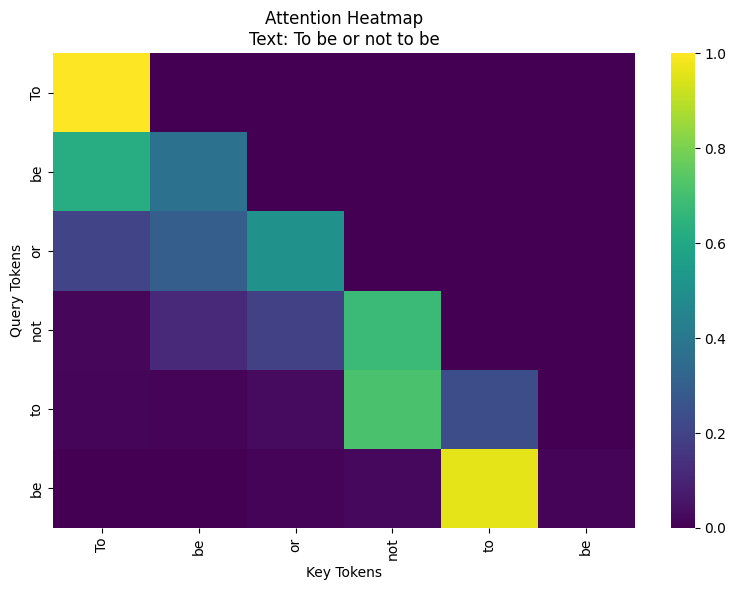

In [150]:
plot_attention_from_text(
    model,
    tokenizer,
    text="To be or not to be",
    device=device
)

#### Sample Sequence: "The king is wise and powerful"

For “The king is wise and powerful,” the attention is again mostly local, but the pattern is slightly more distributed across adjacent tokens. This suggests that the model not only tracks immediate preceding words but also uses nearby contextual information to represent phrase structure. The decomposition of words such as wise and powerful into subword units further shows that attention operates at the learned BPE-token level rather than at the word level.

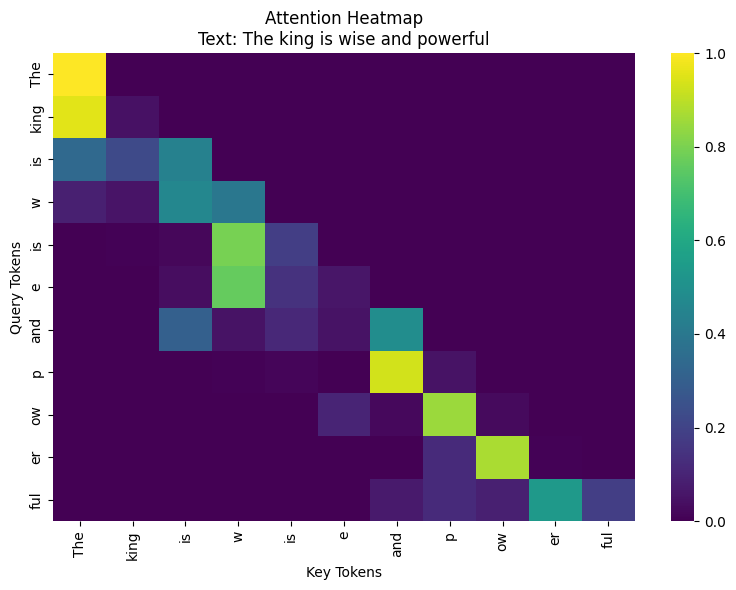

In [206]:
plot_attention_from_text(
    model,
    tokenizer,
    text="The king is wise and powerful",
    device=device
)

Overall, the heatmaps confirm that the Transformer has learned meaningful autoregressive attention patterns, with most heads focusing on recent context while still capturing relevant relationships among nearby tokens.

### h. How Attention Evolves Over Training

Because checkpoints were saved during the main training run, attention evolution can be analyzed without retraining the model. By loading different saved states and visualizing attention for the same sample sequence, we can observe how attention becomes more structured over epochs.

-------------

#### **Analysis**

**Attention Evolution Across Epochs**

The attention maps show a clear progression in structure as training advances.

- At Epoch 1, attention is relatively diffuse and less structured, with tokens attending broadly to multiple previous positions. This indicates that the model has not yet learned meaningful dependencies and is still in an early learning phase.
- By Epoch 5, more recognizable patterns begin to emerge. Attention becomes more concentrated, particularly along the lower triangular region, reflecting the autoregressive nature of the model. Certain tokens start focusing on more relevant previous tokens rather than distributing attention uniformly.
- At Epoch 10, attention becomes significantly sharper and more localized. Strong diagonal and near-diagonal patterns appear, showing that tokens primarily attend to themselves and nearby context. Additionally, some longer-range dependencies begin to form, indicating that the model has learned meaningful relationships between words in the sequence.

**Differences Across Layers**

Comparing Layer 1 and Layer 2, a clear distinction emerges:

- Layer 1 primarily captures local dependencies, with attention concentrated on nearby tokens and a strong diagonal structure.
- Layer 2 exhibits more diverse and distributed attention patterns, suggesting that deeper layers capture more abstract relationships and longer-range interactions.

**Differences Across Heads**

Within the same layer, different heads learn different attention behaviors:

- Some heads (e.g., Head 2) focus on sequential or positional structure, emphasizing nearby tokens.
- Other heads (e.g., Head 4) display more distributed attention, capturing broader contextual relationships.

This supports the idea that multi-head attention enables the model to learn multiple complementary representations of the input.

In [26]:
def plot_attention_evolution(
    config,
    checkpoints,
    tokenizer,
    device,
    text=None,
    dataset=None,
    sample_idx=0,
    layer_idx=0,
    head_idx=0,
    max_tokens=20
):
    if text is not None:
        token_ids = tokenizer.encode(text).ids[:max_tokens]
        x_sample = torch.tensor(token_ids, dtype=torch.long).unsqueeze(0).to(device)
    else:
        x_sample, _ = dataset[sample_idx]
        x_sample = x_sample[:max_tokens].unsqueeze(0).to(device)
        token_ids = x_sample[0].cpu().tolist()

    labels = get_token_labels(tokenizer, token_ids)
    epochs = sorted(checkpoints.keys())

    fig, axes = plt.subplots(
        1,
        len(epochs) + 1,
        figsize=(5 * len(epochs) + 1, 5),
        gridspec_kw={"width_ratios": [1] * len(epochs) + [0.05]}
    )

    heat_axes = axes[:-1]
    cbar_ax = axes[-1]

    for i, (ax, epoch) in enumerate(zip(heat_axes, epochs)):
        temp_model = build_model(config)
        temp_model.load_state_dict(checkpoints[epoch])
        temp_model.eval()

        with torch.no_grad():
            _, attention_maps = temp_model(x_sample, return_attention=True)

        attn = attention_maps[layer_idx][0, head_idx].cpu().numpy()

        sns.heatmap(
            attn,
            xticklabels=labels,
            yticklabels=labels,
            cmap="viridis",
            ax=ax,
            cbar=(i == len(heat_axes) - 1),
            cbar_ax=cbar_ax if i == len(heat_axes) - 1 else None
        )

        ax.set_title(f"Epoch {epoch}")
        ax.set_xlabel("Key Tokens")
        ax.set_ylabel("Query Tokens")
        ax.tick_params(axis="x", rotation=90)

    title_text = text if text is not None else f"sample_idx={sample_idx}"
    fig.suptitle(
        f"Attention Evolution\nLayer {layer_idx+1}, Head {head_idx+1} | Text: {title_text}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

In [27]:
text="The man who spoke to the king is here"

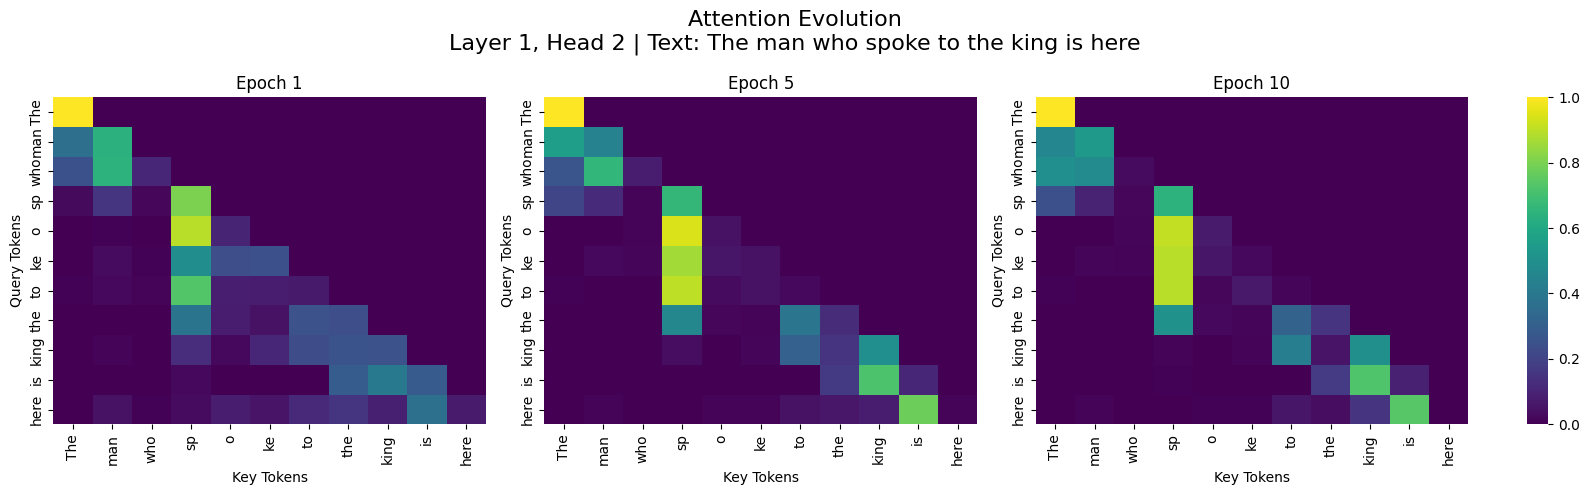

In [37]:
plot_attention_evolution(config=base_config,checkpoints=checkpoints,tokenizer=tokenizer,
                         device=device,text=text,layer_idx=0,head_idx=1,
                         max_tokens=20)

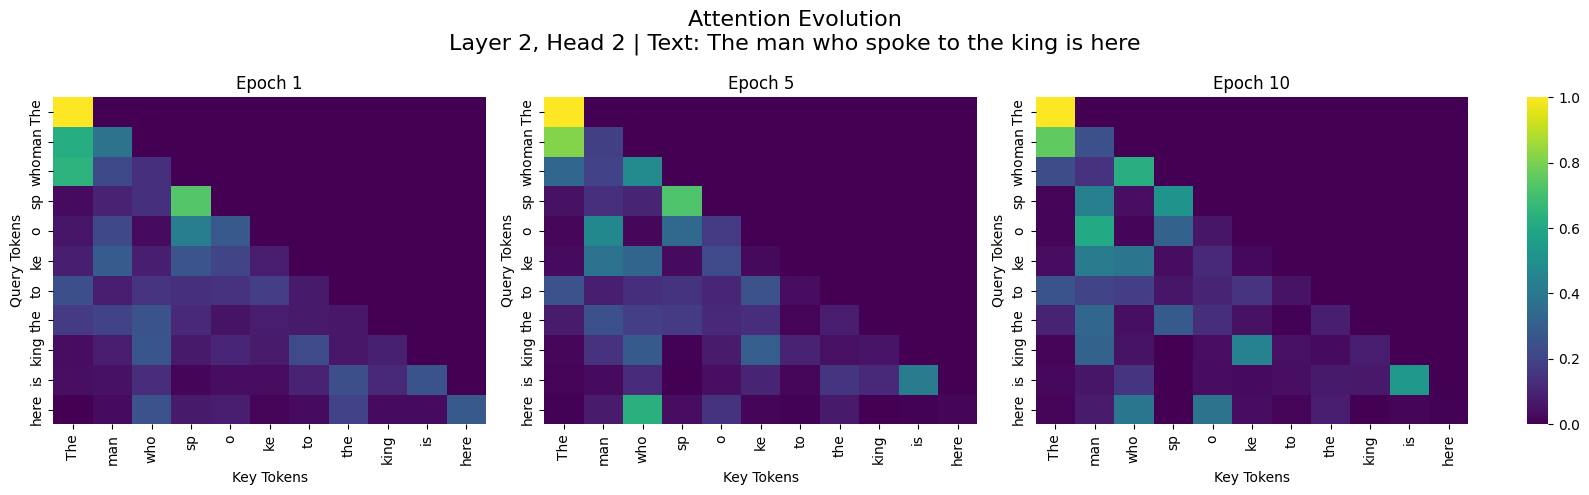

In [38]:
plot_attention_evolution(config=base_config,checkpoints=checkpoints,tokenizer=tokenizer,
                         device=device,text=text,layer_idx=1,head_idx=1,
                         max_tokens=20)

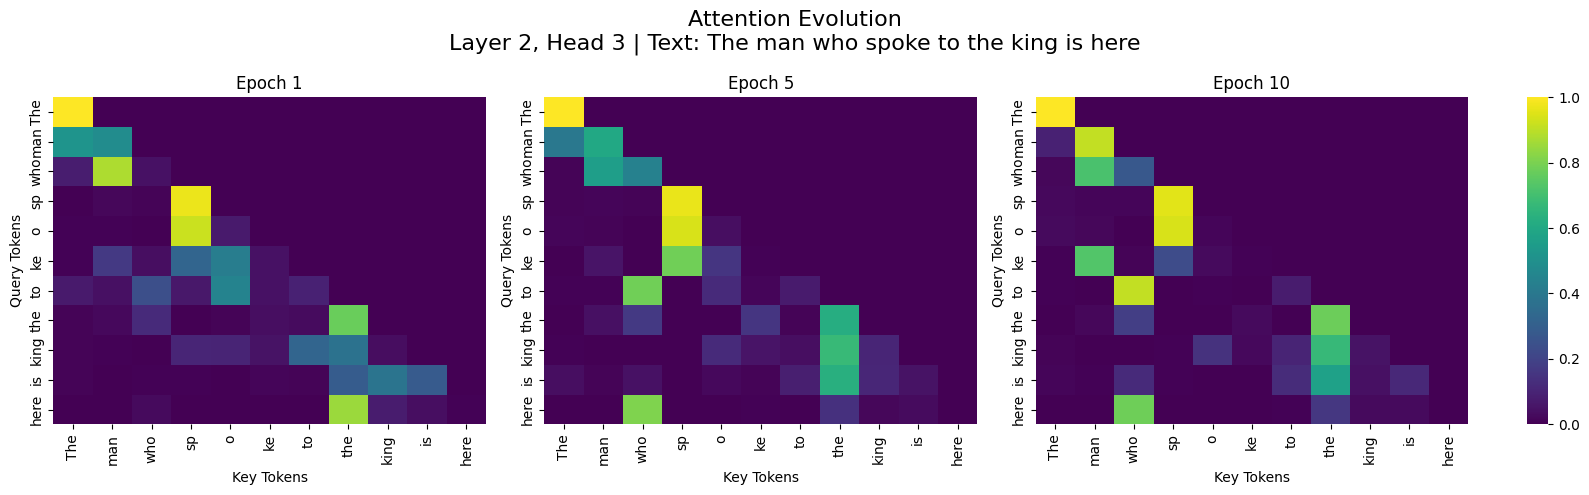

In [40]:
plot_attention_evolution(config=base_config,checkpoints=checkpoints,tokenizer=tokenizer,
                         device=device,text=text,layer_idx=1,head_idx=2,
                         max_tokens=20)

### i. Sample Generation

In addition to quantitative evaluation, sample generation provides a qualitative assessment of model fluency and coherence. Although validation perplexity remains the main performance metric, generated text helps illustrate whether the model has learned locally plausible Shakespeare-like continuations.

---

**Analysis**

To qualitatively evaluate the model, text was generated using short, medium, and long prompts.
- For short prompts such as “To be,” the model produces fluent continuations with a style resembling Shakespearean dialogue, including structured sentences and character-like phrasing.

- For medium prompts (e.g., “The king is wise and”), the model maintains grammatical coherence and continues the sentence in a contextually plausible manner, while also introducing stylistic elements such as speaker annotations (e.g., “KING RICHARD II”).

- For longer prompts such as “To be or not to be, that is the question,” the model preserves stylistic consistency and generates extended text. However, coherence degrades slightly over longer sequences, with occasional nonsensical phrases and semantic drift.

Overall, the model demonstrates strong stylistic learning and reasonable fluency, but struggles with maintaining global coherence, which is expected given the limited model size and training data.

In [111]:
def encode_prompt(tokenizer, prompt):
    encoded = tokenizer.encode(prompt)
    return encoded.ids if hasattr(encoded, "ids") else encoded

In [117]:
def generate_text(
    model,
    tokenizer,
    prompt,
    max_new_tokens=60,
    temperature=0.9,
    device="cpu"
):
    model.eval()

    input_ids = encode_prompt(tokenizer, prompt)
    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            x_cond = input_ids[:, -context_length:]
            logits = model(x_cond)
            next_token_logits = logits[:, -1, :] / temperature
            probs = torch.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            input_ids = torch.cat([input_ids, next_token], dim=1)

    output_ids = input_ids[0].cpu().tolist()
    return tokenizer.decode(output_ids)

In [178]:
sample_text = generate_text(
    model=model,
    tokenizer=tokenizer,
    prompt="To be",
    max_new_tokens=60,
    temperature=0.9,
    device=device
)

print(sample_text)

 To be my hand,
Is time he cans and endlse to show the strength of sixother,
And yet, as he had quite rocky youth seven.
If it were more caught, and


In [187]:
sample_text = generate_text(
    model=model,
    tokenizer=tokenizer,
    prompt="The king is wise and",
    max_new_tokens=60,
    temperature=0.9,
    device=device
)

print(sample_text)

 The king is wise and still that speaks the fair.

KING RICHARD II:
Faith; for I will discredd; for, those bloody look'd
For I have found'd young to-night?
Here


In [181]:
sample_text = generate_text(
    model=model,
    tokenizer=tokenizer,
    prompt="To be or not to be, that is the question",
    max_new_tokens=60,
    temperature=0.9,
    device=device
)

print(sample_text)

 To be or not to be, that is the question of that appear ox,
To aged my brother's face and fees
Will serve first beat proves not
And credulously loving brother Clarence.

MENENIUS


In [173]:
sample_text = generate_text(
    model=model,
    tokenizer=tokenizer,
    prompt="If I were to speak of love,",
    max_new_tokens=60,
    temperature=0.9,
    device=device
)

print(sample_text)

 If I were to speak of love,
So many flowers.'

MENENIUS:
I care my wife.

COMINIUS:
You shall not.
Come, sir;
Condemning, I believe, e


In [166]:
sample_text = generate_text(
    model=model,
    tokenizer=tokenizer,
    prompt="o be or not to be, that is",
    max_new_tokens=100,
    temperature=0.9,
    device=device
)

print(sample_text)

 o be or not to be, that is a goodly heart!
An honourable welkins cheeks sorrow.

KING RICHARD II:
How now, laus?

First Lord:
There is some of me, thou hast not hear them speak ader of him
centeen, a body drickle of a man for old.

MENENIUS:



### j. Runtime and Memory Footprint

It is also important to reflect on the computational bottlenecks of the model. In Transformers, the dominant cost typically comes from the self-attention operation, whose memory and runtime scale quadratically with the sequence length. This makes context length a major factor in computational efficiency.

---

**Analysis**

The main computational bottleneck is the self-attention mechanism, since its attention score tensor has shape $[B,H,T,T]$ and therefore scales quadratically with sequence length. This is reflected in the memory estimates: increasing the context length from 32 to 50 raises the attention memory from 1.00 MB to 2.44 MB, more than doubling the memory cost.

In contrast, the runtime per epoch changes only slightly across the tested settings: 66.44s for context length 32 versus 67.91s for context length 50, and 67.41s for $d_{model}$ = 64 versus 66.50s for $d_{model}$ = 128. This suggests that, in this small-scale setup, runtime is relatively stable, while memory is more clearly affected by context length.

Overall, the dominant bottleneck is attention with longer sequences, because increasing context length directly increases the size of the $T×T$ attention matrix. Model size has a smaller effect here, while sequence length is the primary driver of memory growth.

In [51]:
def estimate_attention_memory(batch_size, num_heads, seq_len, dtype_bytes=4):
    # attention scores tensor shape: [B, H, T, T]
    num_elements = batch_size * num_heads * seq_len * seq_len
    memory_mb = num_elements * dtype_bytes / (1024 ** 2)
    return memory_mb

In [49]:
def compare_runtime(results, label_key):
    for result in results:
        avg_time = sum(result["history"]["epoch_time_sec"]) / len(result["history"]["epoch_time_sec"])
        print(f"{label_key}={result[label_key]} → Avg Epoch Time: {avg_time:.2f}s")

In [46]:
def estimate_transformer_activation_memory(
    batch_size,
    seq_len,
    d_model,
    num_heads,
    d_ff,
    dtype_bytes=4,
):
    # [B, T, d_model]
    input_act = batch_size * seq_len * d_model

    # Q, K, V each: [B, T, d_model]
    qkv_act = 3 * batch_size * seq_len * d_model

    # attention scores: [B, H, T, T]
    attn_scores = batch_size * num_heads * seq_len * seq_len

    # attention output: [B, T, d_model]
    attn_out = batch_size * seq_len * d_model

    # FFN hidden layer: [B, T, d_ff]
    ffn_hidden = batch_size * seq_len * d_ff

    total_elements = input_act + qkv_act + attn_scores + attn_out + ffn_hidden
    memory_mb = total_elements * dtype_bytes / (1024 ** 2)

    return memory_mb

In [47]:
def compare_memory_context(context_lengths, batch_size=64, d_model=128, num_heads=4, d_ff=256):
    print("Comparing Memory Across Context Lengths")
    for ctx_len in context_lengths:
        mem = estimate_transformer_activation_memory(
            batch_size=batch_size,
            seq_len=ctx_len,
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
        )
        print(f"context_length={ctx_len} → Estimated Memory: {mem:.2f} MB")


def compare_memory_model_size(model_dims, batch_size=64, seq_len=50, num_heads=4):
    print("Comparing Memory Across Model Sizes")
    for d_model in model_dims:
        d_ff = 2 * d_model  # consistent with your architecture
        mem = estimate_transformer_activation_memory(
            batch_size=batch_size,
            seq_len=seq_len,
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
        )
        print(f"d_model={d_model} → Estimated Memory: {mem:.2f} MB")

#### Comparing Runtime

In [60]:
compare_runtime(context_results, "context_length")
compare_runtime(model_size_results, "d_model")

context_length=32 → Avg Epoch Time: 65.52s
context_length=50 → Avg Epoch Time: 67.20s
d_model=64 → Avg Epoch Time: 67.46s
d_model=128 → Avg Epoch Time: 67.29s


#### Comparing Memory

In [61]:
compare_memory_context([32, 50], batch_size=64, d_model=128, num_heads=4, d_ff=256)
print()
compare_memory_model_size([64, 128], batch_size=64, seq_len=50, num_heads=4)

Comparing Memory Across Context Lengths
context_length=32 → Estimated Memory: 8.00 MB
context_length=50 → Estimated Memory: 13.38 MB

Comparing Memory Across Model Sizes
d_model=64 → Estimated Memory: 7.91 MB
d_model=128 → Estimated Memory: 13.38 MB
